<a href="https://colab.research.google.com/github/ravi-asati/ravi-writes-abinitio-to-spark/blob/main/read_big_csv_partitions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# spark.read — one big file, many partitions (try it live)

Read one large CSV on a **real two-executor cluster** and watch it break into
partitions, tasks and waves.

Companion to the note: **4. spark.read — one big file, many partitions**
on [ravi-writes.pages.dev](https://ravi-writes.pages.dev/playground/read-big-csv-partitions).

Run top to bottom: **Runtime -> Run all**.

## The data & the requirement

This example demonstrates running Spark on a **`local-cluster[2, 1, 1024]`** setup, meaning two *separate* executor JVMs, each with one core and 1GB of heap, started on the Colab machine. This provides a realistic scenario with two task slots and a scheduler managing work.

To effectively observe this, we generate approximately **64 MB** of CSV data using plain Python, ensuring the input originates outside Spark.

**Requirement:**

1.  Build the session with **`.master("local-cluster[2, 1, 1024]")`** — two executors, one core each.
2.  Read the CSV with an **explicit schema** to avoid the cost of `inferSchema`.
3.  Ensure Spark splits the file into **more partitions than task slots** (aim for 4+), so tasks queue in waves, rather than running concurrently.
4.  Keep only `status = "active"` and write the result to `/content/ravi-writes/data/output/active_customers`.
5.  Report the **number of partitions**, **number of tasks**, and **number of executors** from the run.

> **Partitioning Insight:** Spark's `maxSplitBytes` determines partition size, typically leading to about one partition per core by default. The formula is `maxSplitBytes = min(maxPartitionBytes, max(openCostInBytes, totalBytes / minPartitionNum))`. To observe task queuing, the `maxPartitionBytes` configuration must be reduced, creating more partitions than available cores.

> **Key Observation:** More tasks than slots result in a job processing in **waves**, directly impacting wall-clock time.

In [ ]:
# Precautionary clean up - though /content is a scratch disk
!rm -f /content/ravi-writes/data/input/customers_large.csv

In [ ]:
# Generate the input file with plain Python (NOT Spark)
!pip install -q faker

import csv, os, random
from datetime import date, timedelta
from faker import Faker

INPUT_PATH = "/content/ravi-writes/data/input/customers_large.csv"
os.makedirs(os.path.dirname(INPUT_PATH), exist_ok=True)

fake = Faker()
Faker.seed(42)
random.seed(42)

# Faker once, into a pool -- then compose millions of rows from it
NAMES    = [fake.name() for _ in range(2000)]
CITIES   = [fake.city() for _ in range(300)]
STATUSES = ["active"] * 7 + ["inactive"] * 2 + ["suspended"]   # ~70% active

TARGET_MB = 64                 # crank this up to make the job bigger
START     = date(2020, 1, 1)

with open(INPUT_PATH, "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["customer_id", "name", "city", "signup_date", "status", "balance"])
    cid = 0
    while os.fstat(f.fileno()).st_size < TARGET_MB * 1024 * 1024:
        rows = []
        for _ in range(50_000):          # write in chunks, check the size between them
            cid += 1
            rows.append([
                cid,
                random.choice(NAMES),
                random.choice(CITIES),
                START + timedelta(days=random.randint(0, 2000)),
                random.choice(STATUSES),
                round(random.uniform(0, 5000), 2),
            ])
        w.writerows(rows)
        f.flush()

print(f"{INPUT_PATH} - {os.path.getsize(INPUT_PATH) / 1024**2:.1f} MB, {cid:,} rows")

In [ ]:
# Look at it from the shell, before Spark ever sees it
!ls -lh /content/ravi-writes/data/input/
!head -3 /content/ravi-writes/data/input/customers_large.csv
!wc -l /content/ravi-writes/data/input/customers_large.csv

## The Ab Initio solution

The graph is *Input File → Partition by Round-robin → Read Separated Values → Filter By Expression → Write Separated Values → Output File*.

The shape is the interesting part. The **Input File** reads the CSV as **raw text**, not as a record — a one-field DML, `record string("\n") line; end`. Nothing has been parsed yet. **Partition by Round-robin** then fans those lines across a 2-way layout, and only *after* the flow is parallel does **Read Separated Values** turn each line into a typed record. Split the text first, decide what the text means second — which is exactly what Spark does inside `spark.read`.

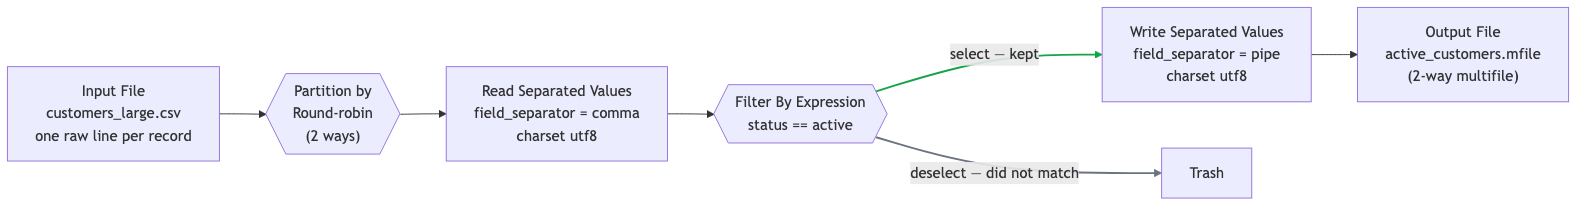

Component for component, that is this notebook:

| Ab Initio | PySpark |
|---|---|
| **Input File** — `customers_large.csv` | `.load(INPUT_PATH)` |
| **Partition by Round-robin**, 2 ways | the file split into partitions — `spark.sql.files.maxPartitionBytes` |
| **Read Separated Values** — `field_separator ","`, `charset utf8`, output DML | `.options(sep=",", header=True, encoding="UTF-8").schema(schema)` |
| **Filter By Expression** — `status == "active"` | `.filter(col("status") == "active")` |
| **Write Separated Values** — `field_separator "\|"`, `charset utf8` | `.option("sep", "\|").option("header", True)` |
| **Output File** — `active_customers.mfile`, 2 data partitions | `.save(OUTPUT_PATH)` → a directory of `part-*` files |

Read Separated Values and Write Separated Values are the *text ↔ record* boundary, and Ab Initio makes you draw it as two components. Spark hides both inside the CSV data source, which is why the `sep` / `header` / `encoding` options look decorative until you have seen the graph — they are the DML.

> **Declared parallelism vs derived parallelism.** In Ab Initio *you* decide the depth: the layout on the Partition by Round-robin says 2 ways, so there are 2 ways, and the multifile has 2 data partitions because you built it that way. Spark never asks. It **derives** the split count from the file size and the config — `maxSplitBytes = min(maxPartitionBytes, max(openCostInBytes, totalBytes / minPartitionNum))` — so the only lever you get is to move a number and let the planner re-decide. That is the single biggest adjustment in this example: `.config("spark.sql.files.maxPartitionBytes", "16m")` is not "make 5 partitions", it is "make each slice at most 16 MB, and tell me afterwards how many that was".
>
> The layout is also decoupled from the machines here. Two executors × 1 core = 2 task slots, but 5 partitions — Spark queues the extra three into a second and third wave. An Ab Initio 2-way layout runs 2 ways, full stop.

> **Two details the diagram glosses over.**
>
> **Round-robin moves every record; Spark's split moves none.** Partition by Round-robin is a real repartition — one serial reader pulls the file and pushes lines out across the flows, one at a time, alternating. Spark instead hands each task a **byte range of the same file** and lets it read its own range directly, so the rows in a partition are contiguous rather than interleaved, and there is no funnel at the front. Same goal — even work per way — by opposite means.
>
> **The header is just another line of text.** After the Input File it is a record like any other, so it has to be dropped before or during parsing rather than assumed away. Spark's `header=True` does that job per split, and only the split that owns byte 0 skips a line — the other four start mid-file and have no header to lose.

## The Spark solution — step by step

In [ ]:
# 1. Install PySpark
!pip install -q pyspark

In [ ]:
# 2. Imports & SparkSession -- a REAL two-executor cluster, not local[*]
import os, pyspark
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, DoubleType, DateType,
)

# local-cluster starts separate executor JVMs, so Spark has to know where it lives.
# pip-installed PySpark does not set SPARK_HOME -- without this, executors fail to launch.
os.environ["SPARK_HOME"] = os.path.dirname(pyspark.__file__)

spark = (
    SparkSession.builder
    .appName("read-big-csv-partitions")
    .master("local-cluster[2, 1, 1024]")     # 2 executors, 1 core each, 1024 MB each
    .config("spark.sql.files.maxPartitionBytes", "16m") #no of parts ~ size_of_file/16m
    .getOrCreate()
)

print("spark version :", spark.version)
print("master        :", spark.sparkContext.master)

In [ ]:
# 3. Declare the schema -- explicit, so Spark reads the file exactly once
schema = StructType([
    StructField("customer_id", IntegerType(), False),
    StructField("name",        StringType(),  True),
    StructField("city",        StringType(),  True),
    StructField("signup_date", DateType(),    True),
    StructField("status",      StringType(),  True),
    StructField("balance",     DoubleType(),  True),
])

In [ ]:
# 4. Read the file and count the partitions.
#    Nothing is read yet -- but the partition count is decided here, at planning time.
#    If the session was already running, .config() above was ignored; force it now:
spark.conf.set("spark.sql.files.maxPartitionBytes", "16m")

INPUT_PATH = "/content/ravi-writes/data/input/customers_large.csv"
df = spark.read.format("csv") \
.options(sep=",", header=True, encoding="UTF-8") \
.schema(schema) \
.load(INPUT_PATH)

slots = spark.sparkContext.defaultParallelism      # total cores across executors
print("partitions :", df.rdd.getNumPartitions())
print("task slots :", slots)

In [ ]:
# 5. Filter and write. THIS is the action -- everything above was only a plan.
from pyspark.sql.functions import col

OUTPUT_PATH = "/content/ravi-writes/data/output/active_customers"

active = df.filter(col("status") == "active")
active.write \
.format("csv") \
.option("sep", "|") \
.option("header", True) \
.option("encoding", "UTF-8") \
.mode("overwrite") \
.save(OUTPUT_PATH)

active.show(5)
active.printSchema()

In [ ]:
# 6. One part-* file per partition -- the same shape as an Ab Initio multifile
!ls -lh /content/ravi-writes/data/output/active_customers/ | head

In [ ]:
# look into sample output
!head -5 /content/ravi-writes/data/output/active_customers/part-00000-cbb0ec91-f4a1-457d-bd67-cebb6f2da2f2-c000.csv

## Seeing what happened

Colab does not show Spark's log4j output -- the JVM writes it to the *kernel's* stderr,
not to the cell, so the `INFO DAGScheduler: Got job 0...` lines never appear. They are not
lost (**Runtime -> View runtime logs** has them), but for this example the Spark UI and its
REST API are far more useful.

**Run these while the session is still alive** -- `spark.stop()` takes the UI and the REST
endpoint down with it.

In [ ]:
# The Spark UI runs on the COLAB VM. localhost:4040 in your own browser is YOUR
# machine, which has no Spark -- so ask Colab to proxy the VM's port and open the
# result in a NEW TAB.
#
# Why a new tab and not an inline iframe: Spark sends X-Frame-Options: SAMEORIGIN on
# every UI response, so the browser refuses to embed it and shows
# "...prod.colab.dev refused to connect" -- which looks exactly like a dead port but
# is really a framing policy. Direct navigation is not blocked, only framing.
from urllib.parse import urlparse
from google.colab import output

# read the port rather than hardcoding 4040: Spark walks up to 4041/4042 if it is taken
port = urlparse(spark.sparkContext.uiWebUrl).port
base = output.eval_js(f"google.colab.kernel.proxyPort({port})")
ui   = base.rstrip("/") + "/jobs/"      # proxyPort returns NO trailing slash
print("Spark UI ->", ui)

# Want it inline instead? Restart the session with
#   .config("spark.ui.allowFramingFrom", "https://colab.research.google.com")
# then serve_kernel_port_as_iframe(port, path='/jobs/', height='600') will render.

In [ ]:
# Spark stop - to kill SparkSession and Spark UI - if you want to start fresh
spark.stop()

## Your turn

Variations to try yourself (no solutions provided):

1. **Give each executor a second core** -- `local-cluster[2, 2, 1024]`. Predict the wave
   pattern *before* you run it, then check whether the wall-clock time halves.
2. **Delete the partition-size setting** and re-run on the default. You will *not* get one
   giant partition -- count what you actually get, and work out which of the two numbers
   Spark is really using to decide. Is the job faster or slower, and why?
3. **Switch back to `local[*]`** and look at what the run reports for executors. Why does
   one of them call itself `driver`, and what does that tell you about where the work
   actually happened?
4. **Re-run with `TARGET_MB = 256`** without touching anything else. Does the task count
   change on its own, or do you have to change something to keep the same parallelism?